In [68]:
import shutil
import os
import sys
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
# import tensorflow_datasets as tfds
import h5py
import torch
import tqdm
import numpy as np
import time
import glob
from math import sqrt
from matplotlib import pyplot as plt

In [81]:
def cal_cmd_vel(cmd_eef_pos, delta = 3):
    diff = cmd_eef_pos[delta:] - cmd_eef_pos[:-delta]
    return np.sqrt(np.sum(diff*diff, axis=1)).mean()

def cal_cmd_state_diff(cmd_eef_pos, state_eef_pos):
    diff = cmd_eef_pos - state_eef_pos
    return np.sqrt(np.sum(diff*diff, axis=1)).mean()

def plot_cmd_state_sys_diff(action_points, state_points, save_name):
    diff = state_points - action_points
    diff = diff.mean(axis = 0)

    plt.figure(figsize=(12, 6))
    plt.bar(['L_X','L_Y','L_Z','R_X','R_Y','R_Z'],diff)
    plt.title("Boxplot of Cmd State Diff")
    plt.ylabel("Diff Value")
    plt.grid(True)
    plt.tight_layout()
    os.makedirs('/root/PI_Official/data/visualization/CmdStatDiff_BoxPlot', exist_ok = True)
    plt.savefig(f'/root/PI_Official/data/visualization/CmdStatDiff_BoxPlot/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return 

In [96]:
# dataset_files = []
# for dataset_path in datapaths:
#     dataset_files += [os.path.join(dataset_path, p) for p in os.listdir(dataset_path) if (person in p and mission in p)]

dataset_files = ['/mnt/pfs-chihiro/20250524/20250524_Y_M106_MeetingRoom_PutPenInBox_LMX_LTJ',]
                #  '/mnt/pfs-chihiro/20250524/20250524_Y_M104_MeetingRoom_PutPenInBox_GSJ_WT01']
stats = {'len':[]}
state_points = []
action_points = []
for h5_path in dataset_files:
    hdf5_file_names = glob.glob(os.path.join(h5_path,'*.hdf5'))
    for hdf5_file_name in tqdm.tqdm(hdf5_file_names):
        h5_file = h5py.File(hdf5_file_name,'r')
        ep = {k:np.array(v) for k,v in h5_file.items()}
        h5_file.close()
        stats['len'].append(ep['robot0_eef_pos'].shape[0])
        state_points.append(np.concatenate([ep['robot0_eef_pos'],ep['robot1_eef_pos']],1))
        action_points.append(np.concatenate([ep['robot0_cmd_eef_pos'], ep['robot1_cmd_eef_pos']],1))
state_points = np.concatenate(state_points, 0)
action_points = np.concatenate(action_points, 0)
print(f'{state_points.shape[0]} vs {action_points.shape[0]}')

100%|██████████| 164/164 [00:47<00:00,  3.46it/s]

216127 vs 216127


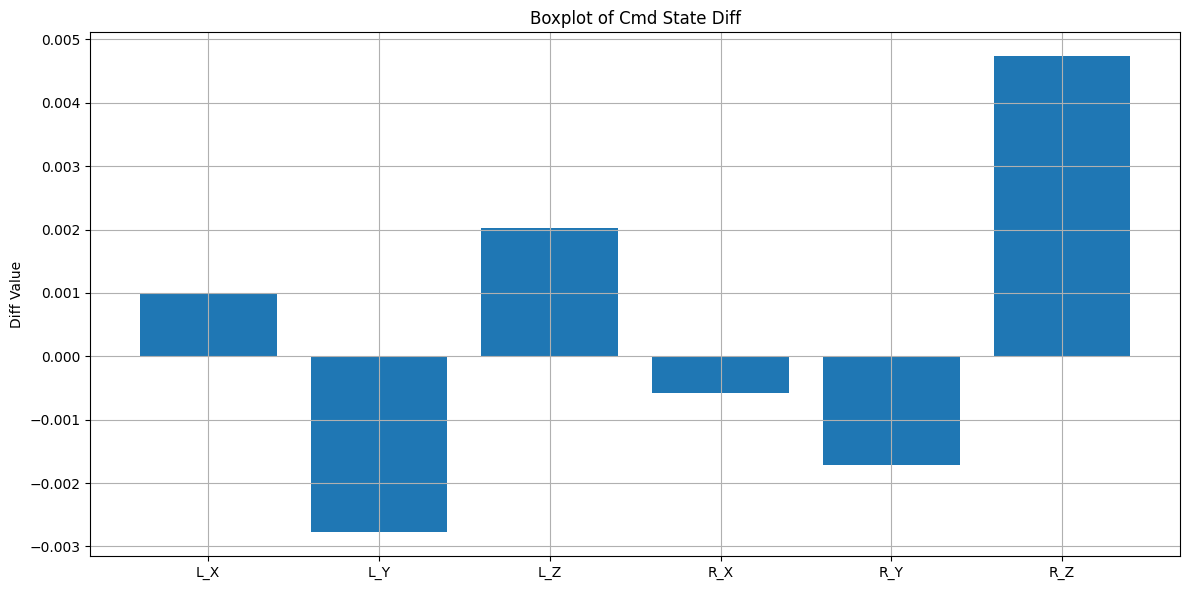

In [97]:
plot_cmd_state_sys_diff(action_points, state_points, 'M106_24')

In [101]:
import os
import cv2
import numpy as np
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
import ffmpeg
import ipdb
import torch
import tqdm
import matplotlib.pyplot as plt
# import seaborn as sns
import matplotlib.patches as patches
from random import sample 
!export XDG_CACHE_HOME=/pfstem/likaiyu/resources/.cache
def plot_robot_xyplane_stats(action_points, state_points, save_name):
    points_np = action_points.numpy()[...,:2]
    points_np2 = state_points.numpy()[...,:2]
    # Plot
    plt.figure(figsize=(8, 6))
    # fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    plt.scatter(points_np[::2, 0], points_np[::2, 1],
                s=2,               # dot size
                c='red',          # dot color
                alpha=.1)        # transparency to emphasize density
    plt.scatter(points_np2[::2, 0], points_np2[::2, 1],
                s=2,               # dot size
                c='blue',          # dot color
                alpha=.1)        # transparency to emphasize density
    plt.scatter(points_np[1::2, 0], points_np[1::2, 1],
                s=2,               # dot size
                c='orange',          # dot color
                alpha=.1)        # transparency to emphasize density
    plt.scatter(points_np2[1::2, 0], points_np2[1::2, 1],
                s=2,               # dot size
                c='green',          # dot color
                alpha=.1)        # transparency to emphasize density
    # patches.Rectangle((-0.6,))
    plt.axis([-0.6,0.6,-1.295,-0.095])
    plt.title('Robot EEF on XY plane')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    legend = plt.legend(['l_action','l_state','r_action','r_state'])
    for handle in legend.legend_handles:
        handle.set_alpha(1)
    plt.savefig(f'/root/PI_Official/data/visualization/XYPlane/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_singledim_stats(action_points, state_points, save_name):
    points_np = action_points.numpy()
    points_np2 = state_points.numpy()
    data = np.concatenate([points_np2[::2], points_np2[1::2]],1)
    # points = np.concatenate([points_np, points_np2], axis = 0)
    # data = points.T
    print(f'data shape {data.shape}')

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, patch_artist=True)
    plt.title("Boxplot of Each EEF Dimension")
    plt.ylabel("EEF Value")
    plt.xticks(range(1, 7), ['L_X','L_Y','L_Z','R_X','R_Y','R_Z'])  # label x-axis from Dim 0 to Dim 13
    plt.grid(True)
    plt.tight_layout()
    os.makedirs('/root/PI_Official/data/visualization/XYZ_BoxPlot', exist_ok = True)
    plt.savefig(f'/root/PI_Official/data/visualization/XYZ_BoxPlot/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def cal_cmd_vel(state_points, delta = 3):
    state_points = state_points.numpy()
    left_points = state_points[::2]
    right_points = state_points[1::2]
    diff = left_points[delta:] - left_points[:-delta]
    print(diff.mean())
    left_mean = np.sqrt(np.sum(diff*diff, axis=1)).mean()
    diff = right_points[delta:] - right_points[:-delta]
    print(diff.mean())
    right_mean = np.sqrt(np.sum(diff*diff, axis=1)).mean()
    return (left_mean + right_mean)/2

def cal_cmd_state_diff(action_points, state_points):
    action_points = action_points.numpy()
    state_points = state_points.numpy()
    diff = action_points - state_points
    return np.sqrt(np.sum(diff*diff, axis=1))

def plot_cmd_state_sys_diff(action_points, state_points, save_name):
    action_points = action_points.numpy()
    state_points = state_points.numpy()
    action_points = np.concatenate([action_points[::2], action_points[1::2]],1)
    state_points = np.concatenate([state_points[::2], state_points[1::2]],1)
    diff = state_points - action_points
    diff = diff.mean(axis = 0)

    plt.figure(figsize=(12, 6))
    plt.bar(['L_X','L_Y','L_Z','R_X','R_Y','R_Z'],diff)
    plt.title("Boxplot of Cmd State Diff")
    plt.ylabel("Diff Value")
    plt.grid(True)
    plt.tight_layout()
    os.makedirs('/root/PI_Official/data/visualization/CmdStatDiff_BoxPlot', exist_ok = True)
    plt.savefig(f'/root/PI_Official/data/visualization/CmdStatDiff_BoxPlot/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return 

def find_outliers(data):
    from scipy.stats import zscore
    z_scores = zscore(data)
    threshold = 3
    outlier_indices = np.where(np.abs(z_scores) > threshold)[0]
    return outlier_indices

In [103]:
!export XDG_CACHE_HOME=/pfstem/likaiyu/resources/.cache
repo_id='YC_MeetingRoom_PutPenInBox_0524_Fix'
sample_num = 10_000

dataset = LeRobotDataset(repo_id, local_files_only=True)
action_points = []
state_points = []
for i in tqdm.tqdm(sample(range(len(dataset)),sample_num)):

    item = dataset[i]
    action_points.append(item['actions'][:3])
    action_points.append(item['actions'][7:10])
    state_points.append(item['observation.state'][:3])
    state_points.append(item['observation.state'][7:10])

action_points = torch.stack(action_points)
state_points = torch.stack(state_points)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MeetingRoom_PutPenInBox_0524_Fix` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MeetingRoom_PutPenInBox_0524_Fix` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/674 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/352 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:01<00:00, 161.33it/s]


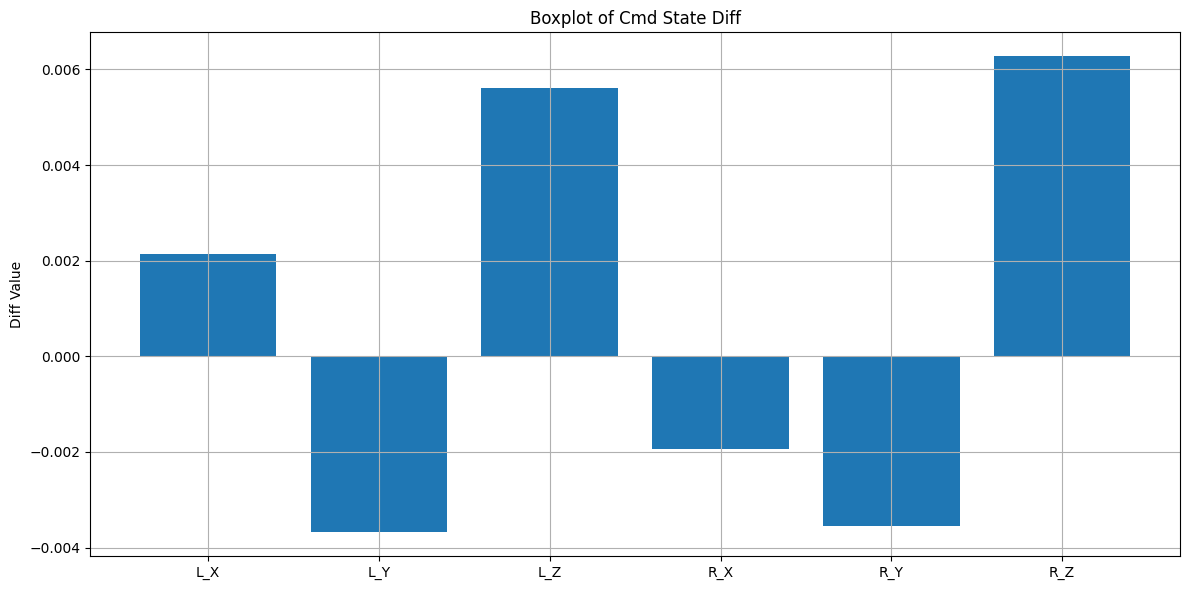

In [104]:
# plot_robot_xyplane_stats(action_points, state_points, repo_id)
# plot_singledim_stats(action_points, state_points, repo_id)
plot_cmd_state_sys_diff(action_points, state_points, repo_id)

In [33]:
cmd_state_diff = cal_cmd_state_diff(action_points, state_points)

# inds = find_outliers(cmd_state_diff)
inds = cmd_state_diff > 0.01
print(f'command state average difference is {cmd_state_diff.mean()}m')
print(f'{inds.sum()*50/sample_num}% points has cmd-state diff larger than 0.01m')
print(f'max cmd-state diff is {cmd_state_diff.max()}m')
# plot_robot_xyplane_stats(action_points[inds], state_points[inds], repo_id + '_outliers')

command state average difference is 0.000733406632207334m
1.5725% points has cmd-state diff larger than 0.01m
max cmd-state diff is 0.043169282376766205m


In [5]:
import os
import cv2
import numpy as np
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
import ffmpeg
import ipdb
import torch
import tqdm
import matplotlib.pyplot as plt
# import seaborn as sns
import matplotlib.patches as patches
from random import sample 

def plot_variant_comparison(action_points, state_points, title="Left Arm", save_name=None):
    """
    Plot comparison of two time-series variants over 7 dimensions.
    
    Args:
        action_points (np.ndarray): Shape (t, 7), first variant.
        state_points (np.ndarray): Shape (t, 7), second variant.
        title (str): Overall title of the plot.
        save_name (str or None): If provided, saves the figure to this path.
    """
    assert action_points.shape == state_points.shape, "Variants must have the same shape"
    assert action_points.shape[1] == 7, "Each variant must have 7 dimensions"
    axis_names = ['X','Y','Z','r','p','y','G']
    max_frame = 300
    action_points = action_points[-max_frame:]
    state_points = state_points[-max_frame:]

    t = action_points.shape[0]
    time = np.arange(t)/30

    fig, axes = plt.subplots(7, 1, figsize=(10, 12), sharex=True, dpi = 300)
    fig.suptitle(title, fontsize=14)

    for i in range(7):
        axes[i].plot(time, action_points[:, i], 'b--o', markersize=2,
               markerfacecolor='blue', markeredgecolor='black', markeredgewidth=0.5,
               label='action', alpha=0.6)
        axes[i].plot(time, state_points[:, i], 'r--o', markersize=2,
               markerfacecolor='red', markeredgecolor='black', markeredgewidth=0.5,
               label='state', alpha=0.6)
        axes[i].set_ylabel(axis_names[i])
        axes[i].grid(True)
        if i == 0:
            axes[i].legend(loc='upper right')

    axes[-1].set_xlabel('Time Step(s)')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    if save_name:
        plt.savefig(f'/root/PI_Official/data/visualization/episode_demo/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def preprocess_rotvec(points):
    assert points.shape[0] > 1
    rot_vec = points[...,3:6]
    rot_vec = rot_vec.numpy()
    for i in range(1, points.shape[0]):
        if np.dot(rot_vec[i], rot_vec[i-1]) < 0:
            rot_vec[i] *= -1
            norm = np.sqrt(np.sum(rot_vec[i]**2))
            rot_vec[i] = rot_vec[i] * (2*np.pi - norm)/norm
            print(f'norm is {np.sqrt(np.sum(rot_vec[i]**2))}')
    points[..., 3:6] = torch.tensor(rot_vec)
    return points

In [4]:
#visualize by episode
# repo_id='YC_MeetingRoom_PutPenInBox_0524_Fix'
repo_id='YC_MeetingRoom_PutPenInBox_0528'
# repo_id = 'MultiTask_7task_0422'
# repo_id = 'HRPI_MultiTask_PutPlateOnRack_0423_29'
dataset = LeRobotDataset(repo_id, episodes = list(range(100)),local_files_only=True)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MeetingRoom_PutPenInBox_0528` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MeetingRoom_PutPenInBox_0528` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/65 [00:00<?, ?it/s]

In [6]:
episode_id = 30
start,end = dataset.episode_data_index['from'][episode_id], dataset.episode_data_index['to'][episode_id]

l_action_points, r_action_points = [],[]
l_state_points, r_state_points = [],[]
for i in tqdm.tqdm(range(start,end)):
    item = dataset[i]
    l_action_points.append(item['actions'][:7])
    r_action_points.append(item['actions'][7:])
    l_state_points.append(item['observation.state'][:7])
    r_state_points.append(item['observation.state'][7:])

l_action_points = torch.stack(l_action_points)
r_action_points = torch.stack(r_action_points)
l_state_points = torch.stack(l_state_points)
r_state_points = torch.stack(r_state_points)

100%|██████████| 1141/1141 [00:07<00:00, 156.27it/s]


In [17]:
l_action_points = preprocess_rotvec(l_action_points)

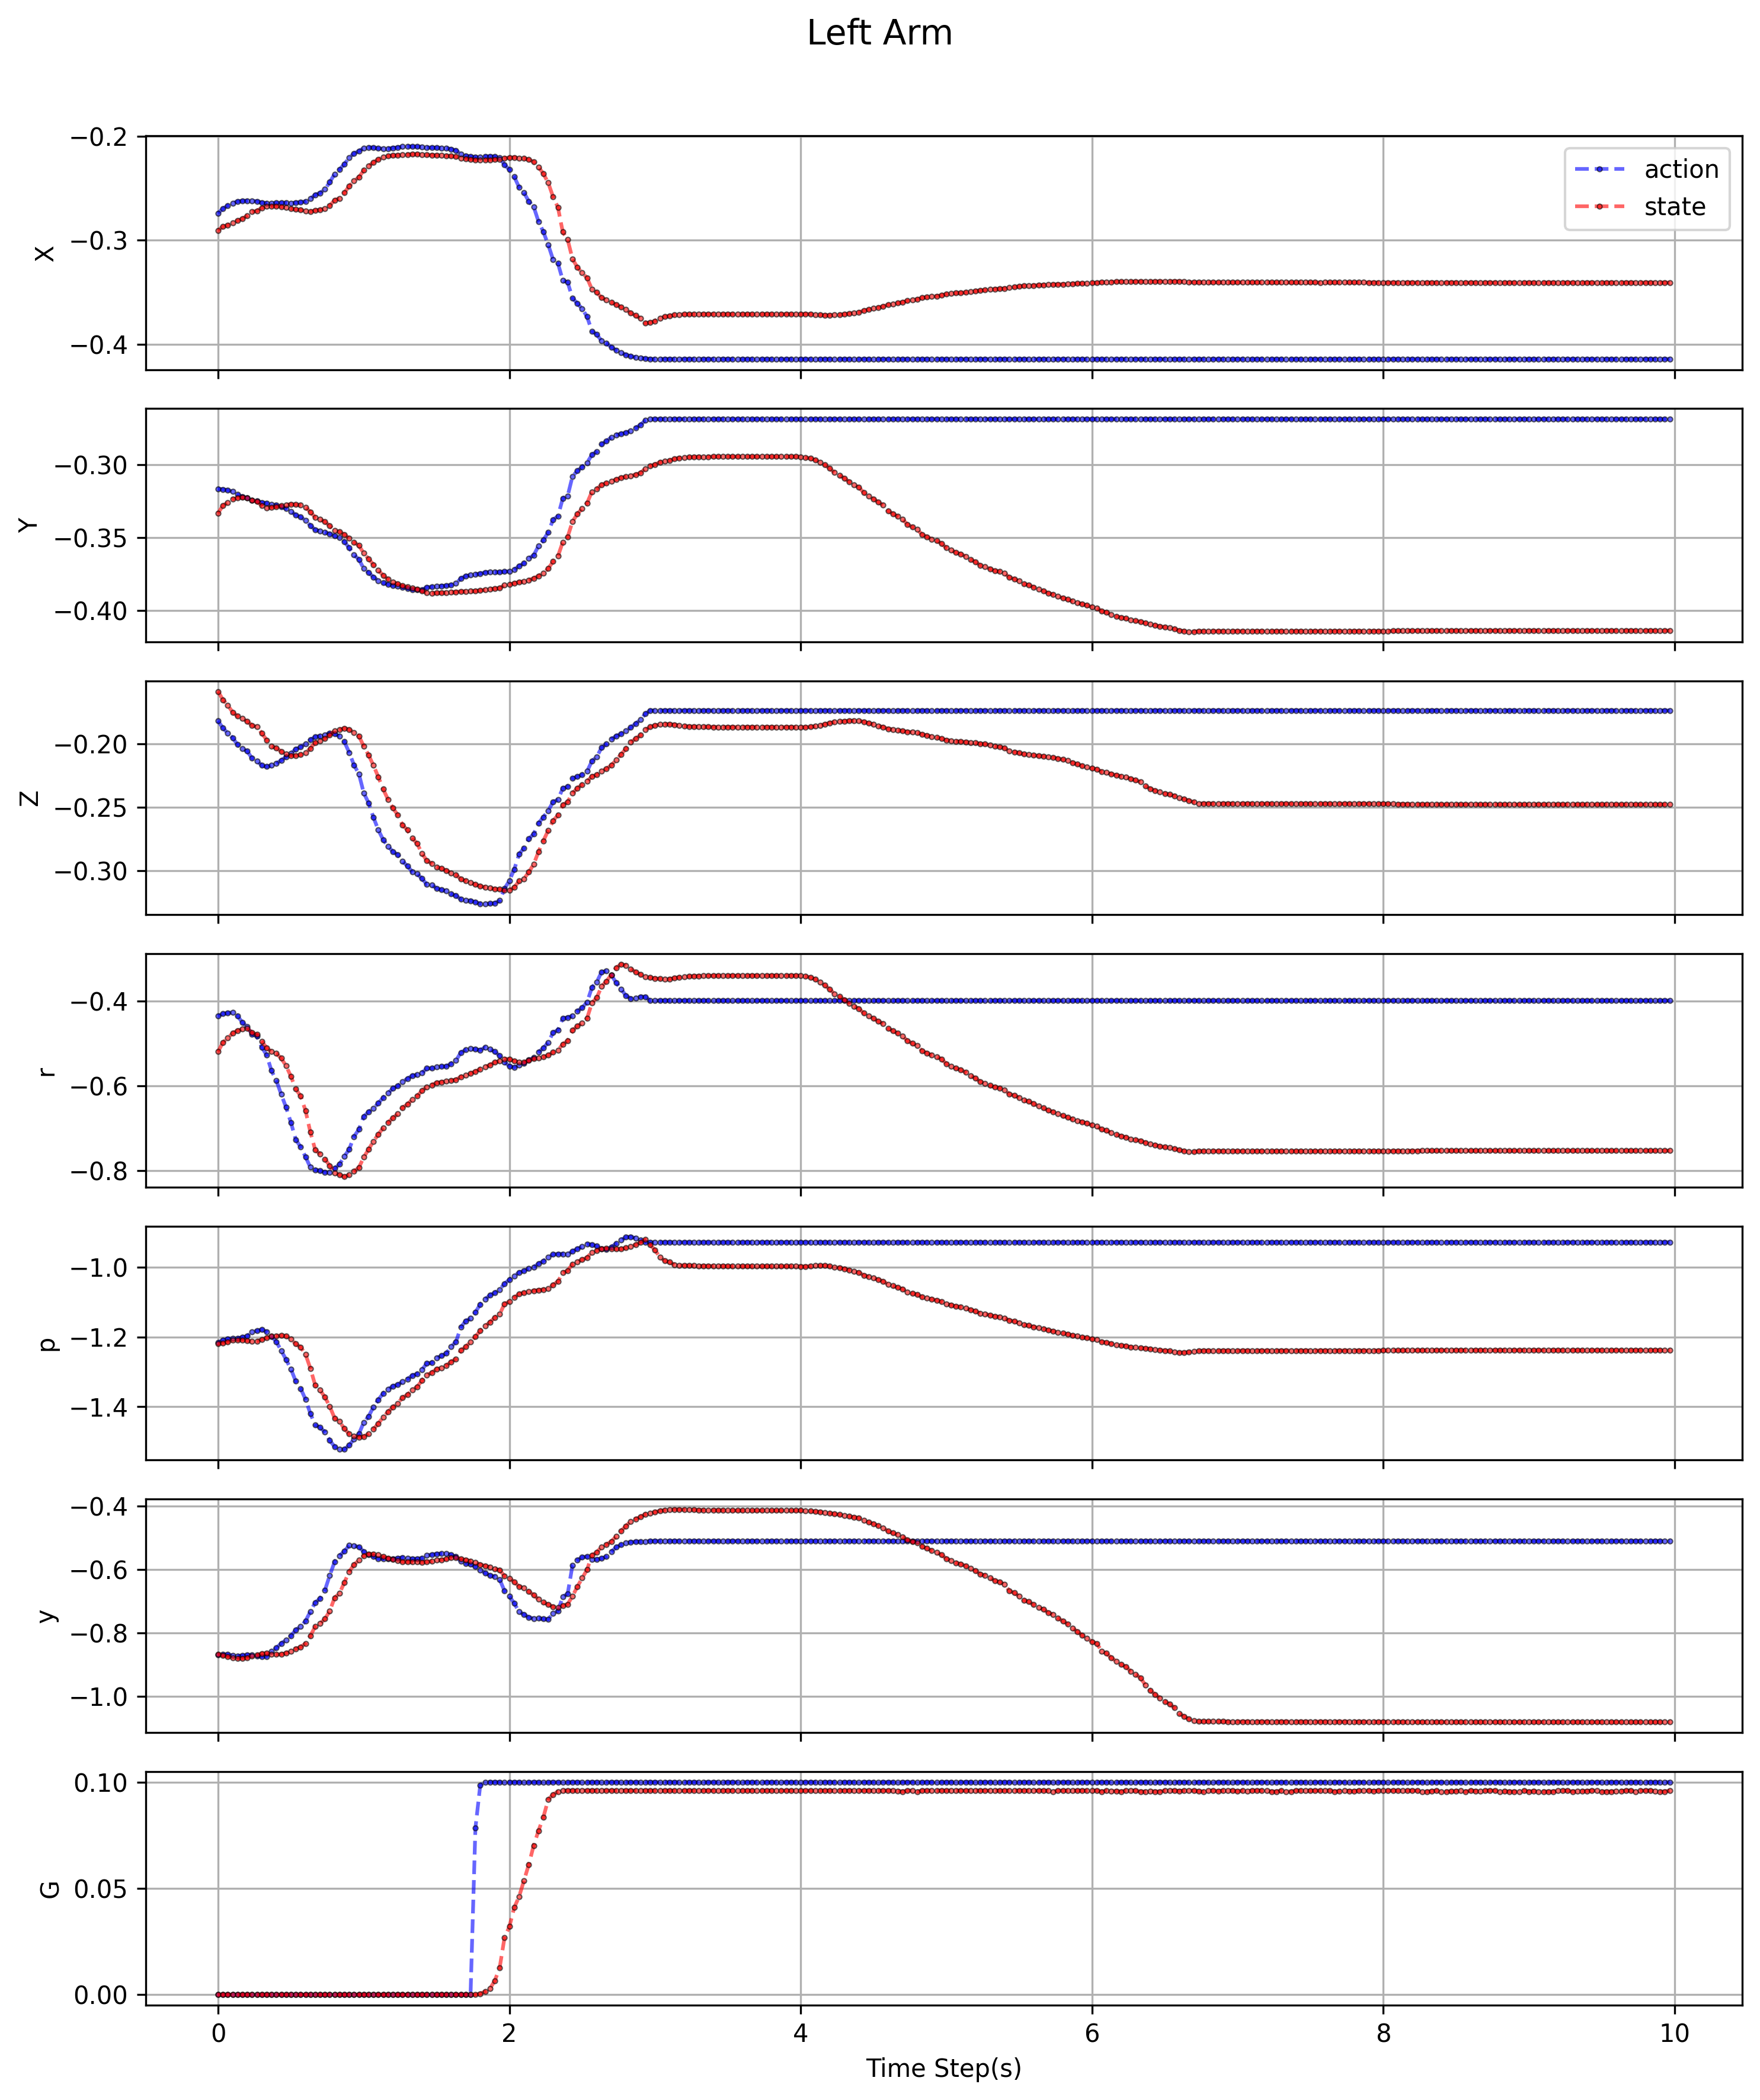

In [7]:
# l_action_points = preprocess_rotvec(l_action_points)
# l_state_points = preprocess_rotvec(l_state_points)
plot_variant_comparison(r_action_points, r_state_points, save_name = repo_id + '_right_' + str(episode_id))

In [14]:
import os
import glob
device = 'PutPenlnBox'
dataset_paths = [
                    # '/mnt/pfs-chihiro/20250509',
                    # '/mnt/pfs-chihiro/20250510'
                    # '/mnt/pfs-chihiro/20250512',
                    '/mnt/pfs-chihiro/20250513',
                    '/mnt/pfs-chihiro/20250514',
                    '/mnt/pfs-chihiro/20250515',
                    '/mnt/pfs-chihiro/20250516',
                    '/mnt/pfs-chihiro/20250517',
                    '/mnt/pfs-chihiro/20250519',
                    '/mnt/pfs-chihiro/20250520',
                    '/mnt/pfs-chihiro/20250521',
                    '/mnt/pfs-chihiro/20250522',
                    '/mnt/pfs-chihiro/20250523',
                    '/mnt/pfs-chihiro/20250524',
                ]
dataset_files = []
for dataset_path in dataset_paths:
    dataset_files += [os.path.join(dataset_path, p) for p in os.listdir(dataset_path) if device in p]


In [10]:
cnt = 0
for f in dataset_files:
    cnt += len(glob.glob(os.path.join(f, '*.hdf5')))
print(f'遗漏条数为{cnt}条')

遗漏条数为1305条


In [12]:
(6119+1403-1305)/(6519 + 1592)

0.7664899519171495